In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import umap
import shap
import hdbscan

from scipy.stats import uniform, norm, multinomial, bernoulli

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report

from sklearn.cluster import KMeans

/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def CVSHAP(X, y, nfolds=10, random_state=1):
    #Establish CV scheme
    CV = KFold(n_splits=nfolds, shuffle=True, random_state=random_state)
    
    ix_training, ix_test = [], []
    # Loop through each fold and append the training & test indices to the empty lists above
    for fold in CV.split(X):
        ix_training.append(fold[0]), ix_test.append(fold[1])

    SHAP_values_per_fold = [] #-#-#
    ## Loop through each outer fold and extract SHAP values 
    for i, (train_outer_ix, test_outer_ix) in enumerate(zip(ix_training, ix_test)): #-#-#
        X_train, X_test = X.iloc[train_outer_ix, :], X.iloc[test_outer_ix, :]
        y_train, y_test = y.iloc[train_outer_ix], y.iloc[test_outer_ix]

        model = xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=random_state)
        fit = model.fit(X_train, y_train)
    
        # Use SHAP to explain predictions
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        for SHAPs in shap_values:
            SHAP_values_per_fold.append(SHAPs) #-#-#

    new_index = [ix for ix_test_fold in ix_test for ix in ix_test_fold]

    sorting_index = [new_index.index(i) for i in range(len(new_index))]

    return np.array(SHAP_values_per_fold)[sorting_index]

def rep_CVSHAP(X, y, nfolds=10, nreps=5, random_states=None):
    if random_states is None:
        random_states = range(nreps)
    
    shaps = np.array([CVSHAP(X, y, nfolds, random_states[i]) for i in range(nreps)])

    return shap.Explanation(values=np.average(shaps, axis=0),
                            feature_names=X.columns,
                            base_values=np.zeros(X.shape + (3,)),
                            data=X)

# Simulate Data

In [3]:
n = 1500
p = 10

X = uniform.rvs(-5, 10, n*p, random_state=21).reshape(n,p)

beta1 = norm.rvs(0, 1, p, random_state=21)
beta1[0] = 4
beta1[1] = 4

beta2 = norm.rvs(0, 1, p, random_state=12543)
beta2[0] = -4
beta2[1] = -4

beta3 = norm.rvs(0, 1, p, random_state=214)

Y1 = np.array([4*x[0]*x[1] + np.dot(x, beta1) for x in X])
Y2 = np.array([4*x[0]*x[1] + np.dot(x, beta2) for x in X])
Y3 = np.array([-4*x[0]*x[1] + np.dot(x, beta3) for x in X])

pr1 = np.exp(Y1)/(1 + np.exp(Y1) + np.exp(Y2))
pr2 = np.exp(Y2)/(1 + np.exp(Y1) + np.exp(Y2))
pr3 = 1/(1 + np.exp(Y1) + np.exp(Y2))

y = [np.where(multinomial.rvs(1, p=p, random_state=291) == 1,)[0][0] for p in zip(pr1, pr2, pr3)]

# Raw Data

In [4]:
X_umap = umap.UMAP(random_state=341).fit_transform(X)

/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


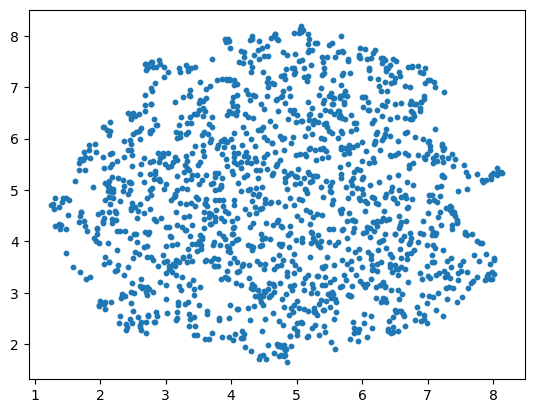

In [5]:
plt.scatter(X_umap[:,0], X_umap[:,1], s=10)

Text(0.5, 1.0, 'Raw data colored according to target class')

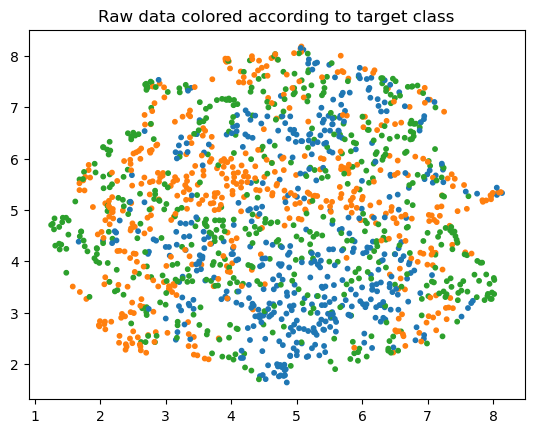

In [6]:
plt.scatter(X_umap[:,0], X_umap[:,1], c=[sns.color_palette()[x] for x in y], s=10)
plt.title("Raw data colored according to target class")

# XGBoost Model

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2123)

In [8]:
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=3234)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.92       156
           1       0.89      0.93      0.91       135
           2       0.90      0.86      0.88       159

    accuracy                           0.90       450
   macro avg       0.90      0.90      0.90       450
weighted avg       0.90      0.90      0.90       450



# SHAP Values

In [9]:
X_df = pd.DataFrame(X, columns=[f"Feature {i}" for i in range(p)])

shap_vals = rep_CVSHAP(X_df, pd.Series(y))

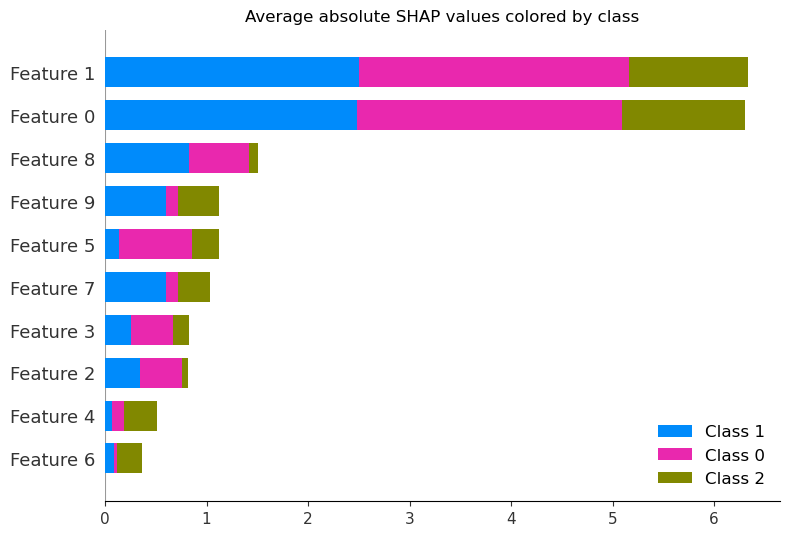

In [10]:
shap.summary_plot(shap_vals, plot_type="bar", max_display=15, show=False)
f = plt.gcf()
ax = plt.gca()

ax.set_title("Average absolute SHAP values colored by class")
ax.set_xlabel("")
plt.show()

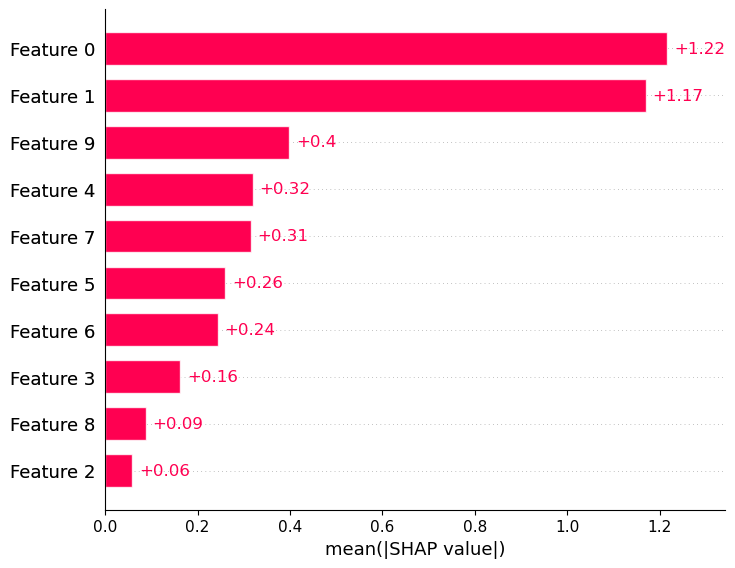

In [11]:
shap.plots.bar(shap_vals[:,:,2])

In [12]:
SHAP_flat = pd.DataFrame(np.asarray([shap_vals.values[i].flatten() for i in range(shap_vals.values.shape[0])]),
                         columns=np.asarray([X_df.columns + "_" + f"Class {i}" for i in range(3)]).flatten('F'))

In [13]:
X_umap_SHAP = umap.UMAP(random_state=2817).fit_transform(SHAP_flat)

/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


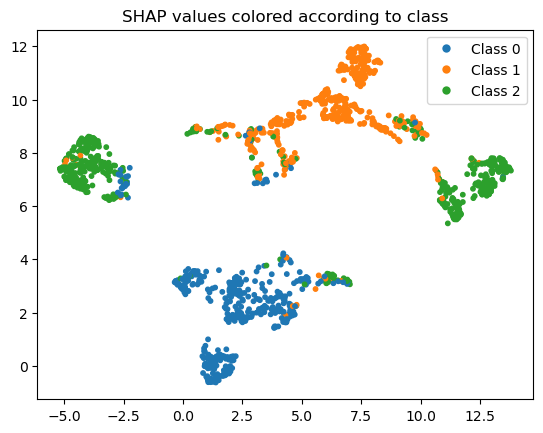

In [14]:
plt.scatter(X_umap_SHAP[:,0], X_umap_SHAP[:,1], c=[sns.color_palette()[int(x)] for x in y], s=10)
plt.title("SHAP values colored according to class")

labels = ["Class 0", "Class 1", "Class 2"]
lp = lambda i: plt.plot([],color=sns.color_palette()[i], mec="none",
                        label=labels[i], ls="", marker="o")[0]
handles = [lp(i) for i in range(3)]
plt.legend(handles=handles, loc="best")

/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


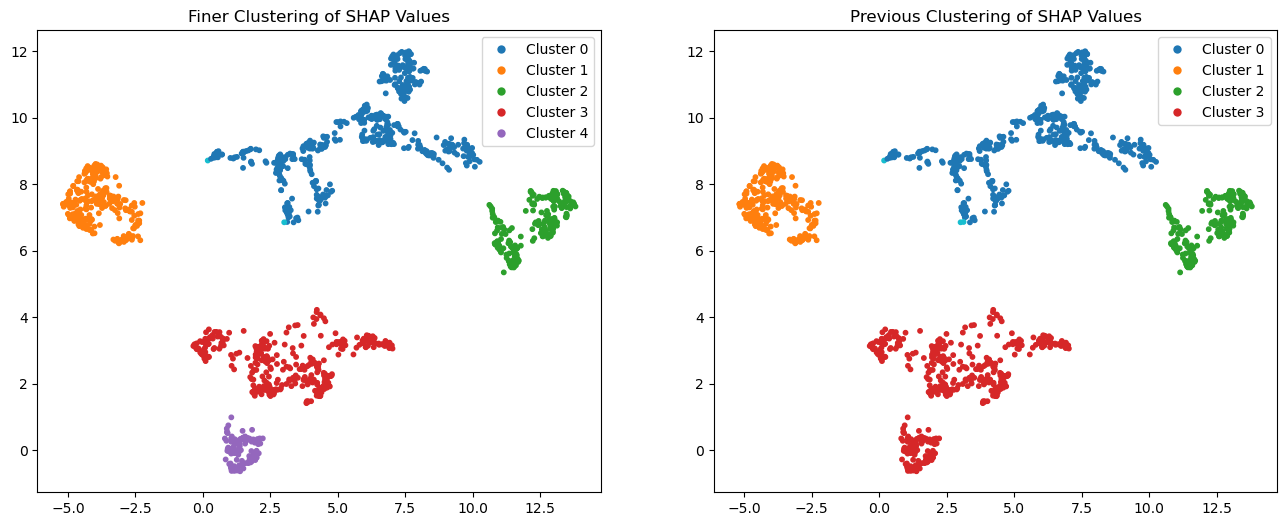

In [58]:
clusterer_fine = hdbscan.HDBSCAN(min_cluster_size=60, min_samples=27)
clusterer_fine.fit(X_umap_SHAP)

mask = clusterer_fine.labels_[:,None] == np.array([1, 0, 2, 4, 3])
val = np.array([0, 1, 2, 3, 4])[mask.argmax(1)]
clusterer_fine.labels_ = np.where(mask.any(1), val, clusterer.labels_)

clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=30)
clusterer.fit(X_umap_SHAP)

mask = clusterer.labels_[:,None] == np.array([3, 0, 2, 1])
val = np.array([0, 1, 2, 3])[mask.argmax(1)]
clusterer.labels_ = np.where(mask.any(1), val, clusterer.labels_)

f, (ax1, ax2) = plt.subplots(1,2)
f.set_size_inches(16, 6)
ax1.scatter(X_umap_SHAP[:,0], X_umap_SHAP[:,1], c=[sns.color_palette()[int(x)] for x in clusterer_fine.labels_], s=10)
ax1.set_title("Finer Clustering of SHAP Values")
ax2.scatter(X_umap_SHAP[:,0], X_umap_SHAP[:,1], c=[sns.color_palette()[int(x)] for x in clusterer.labels_], s=10)
ax2.set_title("Previous Clustering of SHAP Values")

labels = [f"Cluster {i}" for i in range(5)]
lp = lambda i: ax1.plot([],color=sns.color_palette()[i], mec="none",
                        label=labels[i], ls="", marker="o")[0]
handles = [lp(i) for i in range(5)]

ax1.legend(handles=handles, loc="best")

labels2 = [f"Cluster {i}" for i in range(4)]
lp2 = lambda i: ax2.plot([],color=sns.color_palette()[i], mec="none",
                        label=labels2[i], ls="", marker="o")[0]
handles2 = [lp2(i) for i in range(4)]

ax2.legend(handles=handles2, loc="best")

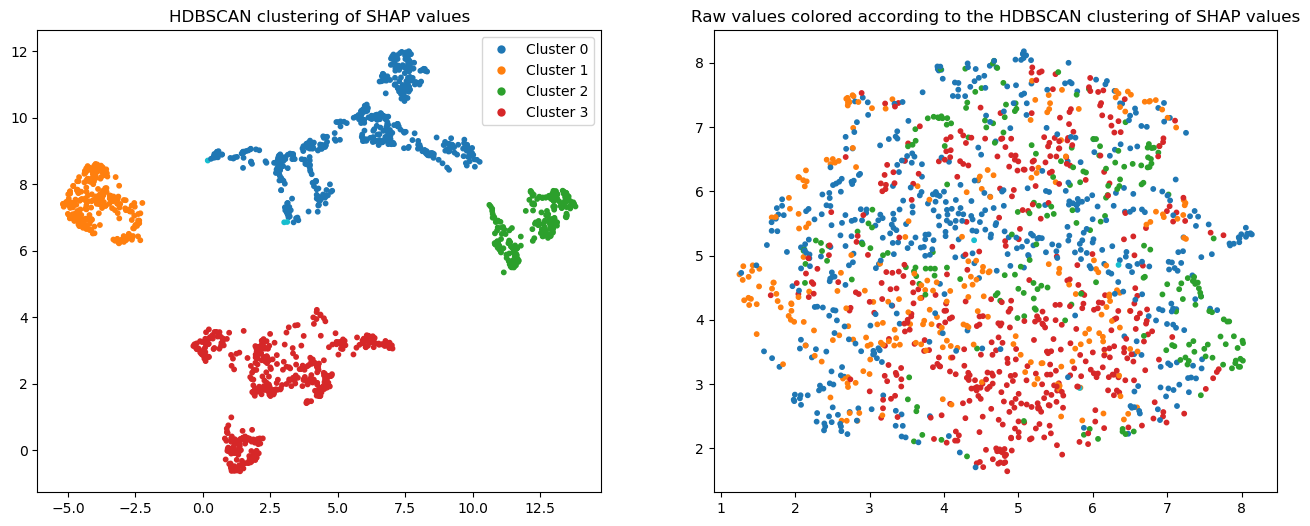

In [56]:
f, (ax1, ax2) = plt.subplots(1,2)
f.set_size_inches(16, 6)
ax1.scatter(X_umap_SHAP[:,0], X_umap_SHAP[:,1], c=[sns.color_palette()[int(x)] for x in clusterer.labels_], s=10)
ax1.set_title("HDBSCAN clustering of SHAP values")
ax2.scatter(X_umap[:,0], X_umap[:,1], c=[sns.color_palette()[int(x)] for x in clusterer.labels_], s=10)
ax2.set_title("Raw values colored according to the HDBSCAN clustering of SHAP values")

labels1 = [f"Cluster {i}" for i in range(4)]
lp1 = lambda i: ax1.plot([],color=sns.color_palette()[i], mec="none",
                         label=labels1[i], ls="", marker="o")[0]
handles1 = [lp1(i) for i in range(4)]

ax1.legend(handles=handles1, loc="best")

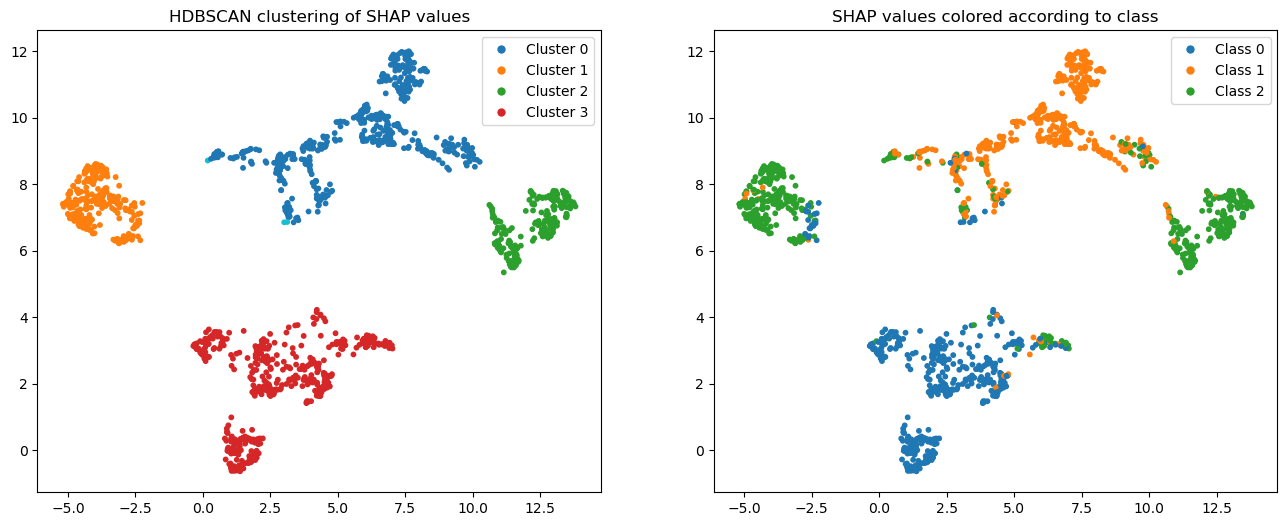

In [57]:
f, (ax1, ax2) = plt.subplots(1,2)
f.set_size_inches(16, 6)
ax1.scatter(X_umap_SHAP[:,0], X_umap_SHAP[:,1], c=[sns.color_palette()[int(x)] for x in clusterer.labels_], s=10)
ax1.set_title("HDBSCAN clustering of SHAP values")
ax2.scatter(X_umap_SHAP[:,0], X_umap_SHAP[:,1], c=[sns.color_palette()[int(x)] for x in y], s=10)
ax2.set_title("SHAP values colored according to class")

labels = [f"Cluster {i}" for i in range(4)]
lp = lambda i: ax1.plot([],color=sns.color_palette()[i], mec="none",
                        label=labels[i], ls="", marker="o")[0]
handles = [lp(i) for i in range(4)]

ax1.legend(handles=handles, loc="best")

labels2 = ["Class 0", "Class 1", "Class 2"]
lp2 = lambda i: plt.plot([],color=sns.color_palette()[i], mec="none",
                         label=labels2[i], ls="", marker="o")[0]
handles2 = [lp2(i) for i in range(3)]
ax2.legend(handles=handles2, loc="best")

In [51]:
SHAP_group_df = pd.concat([pd.Series(clusterer_fine.labels_, name="Cluster"), SHAP_flat], axis=1)
# SHAP_group_df.to_csv("../DATA/SHAP_groups_sim_fine.csv")

In [59]:
raw_heat_df = pd.concat([pd.Series(clusterer_fine.labels_, name="Cluster"), pd.DataFrame(X)], axis=1).groupby('Cluster').mean()[[0, 1, 8, 5]]
raw_heat_df.drop(-1, inplace=True)

Text(0.5, 1.0, 'Heatmap of Top Features Across Clusters')

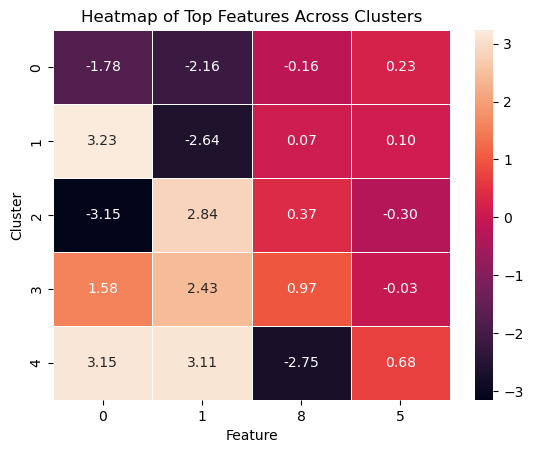

In [60]:
f, ax = plt.subplots()

sns.heatmap(raw_heat_df, annot=True, linewidth=0.5, fmt=".2f", ax=ax)
ax.set(xlabel = "Feature", ylabel="Cluster")
ax.set_title("Heatmap of Top Features Across Clusters")